In [4]:
import os, glob, re, math, numpy as np, nibabel as nb, tifffile as tiff, pandas as pd
import matplotlib.pyplot as plt
import sys, importlib
sys.path.insert(0, "/data/neuralabc/johmat/microscopy_scripts/macaque_CB")
import slice_registration_functions as srf
importlib.reload(srf)
from slice_registration_functions import (apply_coordinate_mapping_2d, downsample_image,
                                           build_centroid_image)

def warp_points(points, maps):
    out = np.asarray(points, float)
    for m in maps:
        out = apply_inverse_coordinate_mapping_2d(out, m)   # your inline def cell, stage order
    return out

def rasterize_counts(pts, shape):
    img = np.zeros(shape, np.float32)
    v = np.isfinite(pts).all(1)
    rr = np.floor(pts[v, 0]).astype(np.int64)
    cc = np.floor(pts[v, 1]).astype(np.int64)
    inb = (rr >= 0) & (rr < shape[0]) & (cc >= 0) & (cc < shape[1])
    np.add.at(img, (rr[inb], cc[inb]), 1.0)   # accumulate, do not overwrite
    return img

def apply_inverse_coordinate_mapping_2d(points, invmap, interpolation='linear',
                                         fill_value=np.nan):
    """
    Apply a single 2D inverse coordinate mapping to point coordinates.

    Point analogue of apply_coordinate_mapping_2d. That samples an image at every
    output pixel; this samples the inverse field at every point location, so counts
    are preserved exactly: one point in, one coordinate out (fill_value if it warps
    outside the field). Nothing is rasterized.

    invmap is the *_ants-invmap field: defined on the SOURCE grid, value at [a0,a1]
    = (out0, out1) absolute coordinates in the next (target) grid. Points flow
    source->target, same direction as image data, so cascade these in the SAME
    order you cascade apply_coordinate_mapping_2d (innermost call = stage 1).

    Parameters
    ----------
    points : (N,2) array
        Coords in (axis0, axis1) order, on the same grid as invmap.
    invmap : nibabel image or (mx,my,2) ndarray
        Inverse coordinate field. Last dim is [axis0, axis1] target coords.
    interpolation : {'linear','nearest'}
    fill_value : float
        Value for out-of-bounds points (default NaN).

    Returns
    -------
    (N,2) ndarray in the target grid. NaN/fill rows left the field. Returns an
    array, not a nibabel image, because points are not an image.
    """
    from scipy.ndimage import map_coordinates

    map_data = invmap.get_fdata() if hasattr(invmap, 'get_fdata') else np.asarray(invmap)
    order = 1 if interpolation == 'linear' else 0
    pts = np.asarray(points, dtype=float)

    a0 = map_coordinates(map_data[:, :, 0], [pts[:, 0], pts[:, 1]],
                         order=order, mode='constant', cval=np.nan)
    a1 = map_coordinates(map_data[:, :, 1], [pts[:, 0], pts[:, 1]],
                         order=order, mode='constant', cval=np.nan)

    out = np.stack([a0, a1], axis=1)
    out[~np.isfinite(out).all(axis=1)] = fill_value
    return out


nighres not found, skipping


In [30]:
def slice_full_shape(zid):
    mfile = glob.glob(os.path.join(mask_dir, f"*zefirID_{zid}_*mask*.ome.tif"))
    assert len(mfile) == 1, f"{zid}: {mfile}"
    with tiff.TiffFile(mfile[0]) as t:
        return tuple(int(x) for x in t.series[0].shape[:2])   # H, W, no pixel decode

def prep_points(pts_full, full_shape, src_grid_shape):
    """Mirror the validated forward prep: downsample_image(prop_pad=0) -> center_crop_or_pad_2d(src.shape)."""
    H, W = full_shape
    ds_h, ds_w = math.ceil(H / rescale), math.ceil(W / rescale)
    Sh, Sw = src_grid_shape
    off = np.array([(max(Sh - ds_h, 0) // 2) - (max(ds_h - Sh, 0) // 2),
                    (max(Sw - ds_w, 0) // 2) - (max(ds_w - Sw, 0) // 2)], float)
    pts_src = np.floor(pts_full / rescale) + off
    inb = ((pts_src >= 0) & (pts_src < np.array(src_grid_shape))).all(1)
    return pts_src[inb], inb, off

def process_slice(zid, stem, inv_paths):
    invs = [nb.load(p) for p in inv_paths]
    src_nii = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz"))   # the _downsample_10p002um_pix source
    src_grid_shape = src_nii.shape[:2]
    assert src_grid_shape == invs[0].shape[:2], \
        f"{stem}: source {src_grid_shape} != coreg0nl invmap {invs[0].shape[:2]}"
    m_last = nb.load(os.path.join(reg_dir, f"{stem}_{fname_suffixes[-1]}-map.nii.gz"))
    target_shape, target_affine = m_last.shape[:2], m_last.affine

    g = df_all[df_all["zefir_id"] == zid]
    pts_full = g[["row", "col"]].to_numpy(float)
    pts_src, inb, off = prep_points(pts_full, slice_full_shape(zid), src_grid_shape)
    pts_warp = warp_points(pts_src, invs)
    lost = ~np.isfinite(pts_warp).all(1)
    counts = rasterize_counts(pts_warp[~lost], target_shape)
    st = dict(src=src_grid_shape, target=target_shape, off=off.tolist(),
              n=int(len(inb)), inb=int(inb.sum()), lost=int(lost.sum()), counted=int(counts.sum()))
    return counts, target_affine, st

In [34]:
mask_dir     = "/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/filtered_binary_masks"
centroid_csv = "/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/filtered_binary_masks/centroids.csv"
reg_dir      = "/data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5"
out_dir      = "/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/registered_centroids"
os.makedirs(out_dir, exist_ok=True)

mask_res = 0.3449 # um per pixel in the original mask images
invmap_res = 50 #base res is 10um, mult by the rescale factor in the dir name

rescale  = int(invmap_res / mask_res)       
# rescale = 145          
PROP_PAD = 0.2                # the pipeline default. confirm with the test overlay below

fname_suffixes = [
    "coreg0nl_ants",
    "coreg12nl_win12_rigsyn_4_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter3_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter4_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter5_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter6_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter7_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter8_ants",
    "coreg12nl_win12_rigsyn_4_groupwise_iter9_ants",
]

def stage_dir(suffix, zid):
    return os.path.join(reg_dir, f"init_translation_slice_{zid}") if suffix == "coreg0nl_ants" else reg_dir

In [23]:
rescale

144

In [ ]:
df_all = pd.read_csv(centroid_csv)
df_all["zefir_id"] = df_all["file"].str.extract(r"zefirID_(\d+)")

# {base_slice}_downsample_10p002um_pix.nii.gz

def discover_slice(zid):
    initd = os.path.join(reg_dir, f"init_translation_slice_{zid}")
    hits = glob.glob(os.path.join(initd, f"zefir_{zid}__*_coreg0nl_ants-invmap.nii.gz"))
    if not hits:
        return None
    stem = os.path.basename(hits[0]).replace("_coreg0nl_ants-invmap.nii.gz", "")
    inv_paths = [os.path.join(stage_dir(s, zid), f"{stem}_{s}-invmap.nii.gz") for s in fname_suffixes]
    if not all(os.path.exists(p) for p in inv_paths):
        return None
    return stem, inv_paths

manifest = {zid: discover_slice(zid) for zid in sorted(df_all["zefir_id"].unique())}
have = [z for z, d in manifest.items() if d]
miss = [z for z, d in manifest.items() if not d]
print(f"processable: {len(have)} | missing maps: {len(miss)}")
print("missing:", miss)

processable: 132 | missing maps: 2
missing: ['0203', '0204']


In [32]:
zid = have[0]; stem = manifest[zid][0]
src = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz")).shape[:2]
inv = nb.load(manifest[zid][1][0]).shape[:2]
print("source:", src, "| coreg0nl invmap:", inv, "| equal:", src == inv)

source: (600, 727) | coreg0nl invmap: (600, 727) | equal: True


off: [79. 90.] src_grid: (600, 727)
full row/col range: [2790.  337.] [62442. 73090.]
prepped row/col range: [98. 92.] [512. 597.]
tissue row range: 86 513 | tissue col range: 103 622


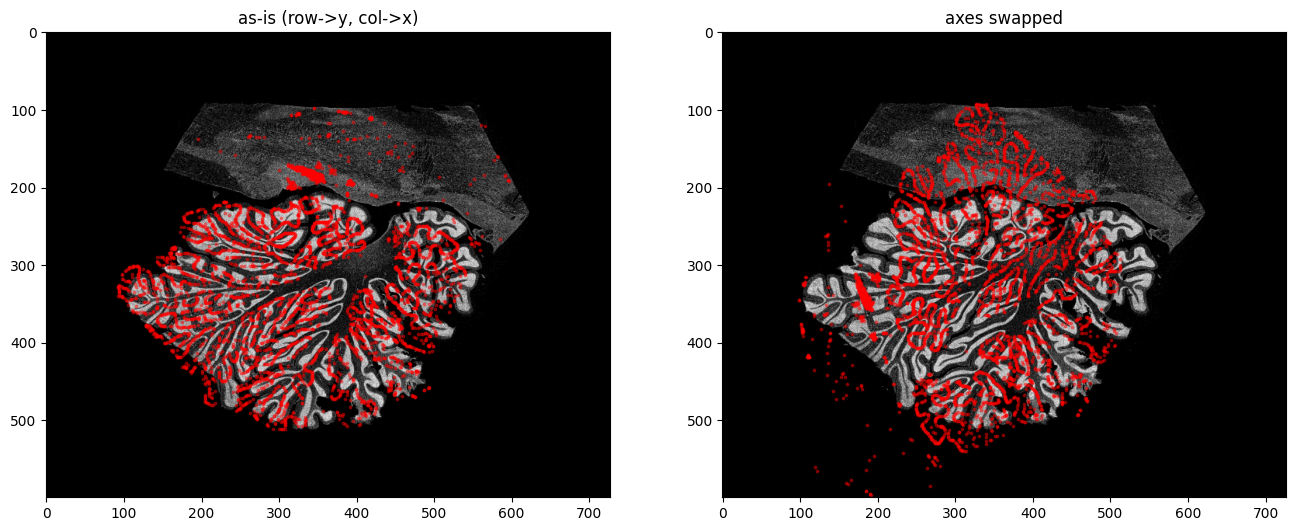

In [36]:
zid = have[0]; stem = manifest[zid][0]
src_img = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz")).get_fdata()
if src_img.ndim == 3: src_img = src_img[..., 0]
src_grid = src_img.shape[:2]
pts_full = df_all.loc[df_all.zefir_id == zid, ["row", "col"]].to_numpy(float)
ps, inb, off = prep_points(pts_full, slice_full_shape(zid), src_grid)

print("off:", off, "src_grid:", src_grid)
print("full row/col range:", pts_full.min(0), pts_full.max(0))
print("prepped row/col range:", ps.min(0), ps.max(0))

# tissue bbox in the source image
ys, xs = np.where(src_img > 0)
print("tissue row range:", ys.min(), ys.max(), "| tissue col range:", xs.min(), xs.max())

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(src_img, cmap="gray")
ax[0].scatter(ps[:, 1], ps[:, 0], s=3, c="red", alpha=.4); ax[0].set_title("as-is (row->y, col->x)")
ax[1].imshow(src_img, cmap="gray")
ax[1].scatter(ps[:, 0], ps[:, 1], s=3, c="red", alpha=.4); ax[1].set_title("axes swapped")
plt.show()

In [39]:
zid = have[0]; stem, inv_paths = manifest[zid]
invs = [nb.load(p) for p in inv_paths]
m1 = nb.load(os.path.join(reg_dir, f"init_translation_slice_0114/{stem}_{fname_suffixes[0]}-map.nii.gz"))
m2 = nb.load(os.path.join(reg_dir, f"{stem}_{fname_suffixes[1]}-map.nii.gz"))

sg = invs[0].shape[:2]
probe = np.array([[sg[0]*.3, sg[1]*.3], [sg[0]*.5, sg[1]*.5],
                  [sg[0]*.7, sg[1]*.6], [sg[0]*.4, sg[1]*.8]])
fwd  = warp_points(probe, [invs[0], invs[1]])          # src -> stage2 via invmaps
back = warp_points(fwd,   [m2, m1])                    # stage2 -> src via fwd maps, reversed order
print("residual (px):\n", back - probe)

residual (px):
 [[ 0.03547807 -0.03967602]
 [ 0.00147101  0.00123334]
 [-0.00787384 -0.00976819]
 [-0.00042286  0.00024496]]


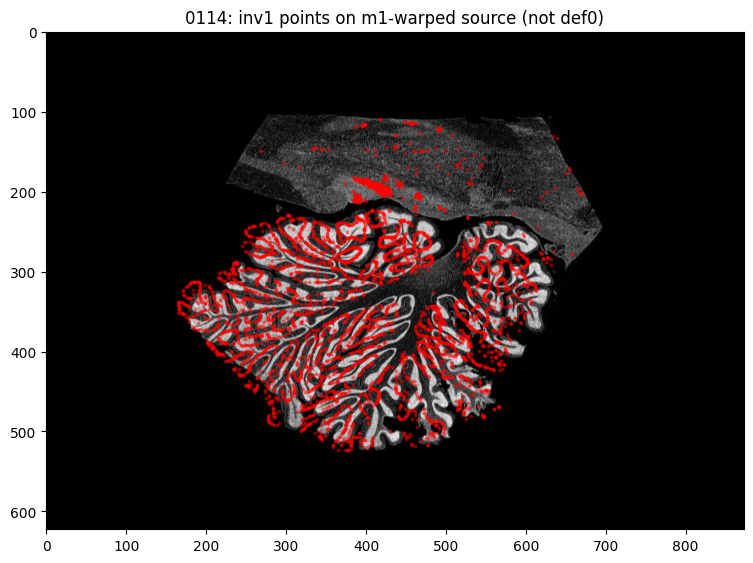

In [44]:
zid = have[0]; stem, inv_paths = manifest[zid]
inv1 = nb.load(inv_paths[0])
m1   = nb.load(os.path.join(reg_dir, f"init_translation_slice_0114/{stem}_{fname_suffixes[0]}-map.nii.gz"))
src_nii = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz"))

warped_img = apply_coordinate_mapping_2d(src_nii, m1).get_fdata()   # validated forward fn
if warped_img.ndim == 3: warped_img = warped_img[..., 0]

pts_full = df_all.loc[df_all.zefir_id == zid, ["row", "col"]].to_numpy(float)
ps, inb, off = prep_points(pts_full, slice_full_shape(zid), inv1.shape[:2])
pw = warp_points(ps, [inv1]); v = np.isfinite(pw).all(1)

plt.figure(figsize=(9, 9)); plt.imshow(warped_img, cmap="gray")
plt.scatter(pw[v, 1], pw[v, 0], s=3, c="red", alpha=.4)
plt.title(f"{zid}: inv1 points on m1-warped source (not def0)"); plt.show()

In [51]:
inv_pathszid = have[0]; stem = manifest[zid][0]
src  = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz"))
seq  = src
for s in fname_suffixes:
    if s == fname_suffixes[0]:
        seq = apply_coordinate_mapping_2d(seq, nb.load(os.path.join(reg_dir, f"init_translation_slice_0114/{stem}_{s}-map.nii.gz")))
    else:
        seq = apply_coordinate_mapping_2d(seq, nb.load(os.path.join(reg_dir, f"{stem}_{s}-map.nii.gz")))
seq  = seq.get_fdata(); seq = seq[..., 0] if seq.ndim == 3 else seq
def0 = nb.load(os.path.join(reg_dir, f"{stem}_{fname_suffixes[-1]}-def0.nii.gz")).get_fdata()
def0 = def0[..., 0] if def0.ndim == 3 else def0
print("forward seq vs def0 max err:", np.abs(seq - def0).max())

forward seq vs def0 max err: 0.0008842019674624169


In [53]:
from scipy.ndimage import map_coordinates
inv1 = nb.load(inv_paths[0]).get_fdata()
m1d  = nb.load(os.path.join(reg_dir, f"init_translation_slice_0114/{stem}_{fname_suffixes[0]}-map.nii.gz")).get_fdata()
sg = inv1.shape[:2]
gx, gy = np.meshgrid(np.linspace(sg[0]*.2, sg[0]*.8, 5),
                     np.linspace(sg[1]*.2, sg[1]*.8, 5), indexing="ij")
x = np.stack([gx.ravel(), gy.ravel()], 1)
def samp(f, p):
    return np.stack([map_coordinates(f[:,:,0], [p[:,0], p[:,1]], order=1, mode="constant", cval=np.nan),
                     map_coordinates(f[:,:,1], [p[:,0], p[:,1]], order=1, mode="constant", cval=np.nan)], 1)
print("m1(inv1(x)) - x  max:", np.nanmax(np.abs(samp(m1d, samp(inv1, x)) - x)))
print("inv1(m1(x)) - x  max:", np.nanmax(np.abs(samp(inv1, samp(m1d, x)) - x)))

m1(inv1(x)) - x  max: 2.842170943040401e-14
inv1(m1(x)) - x  max: 2.842170943040401e-14


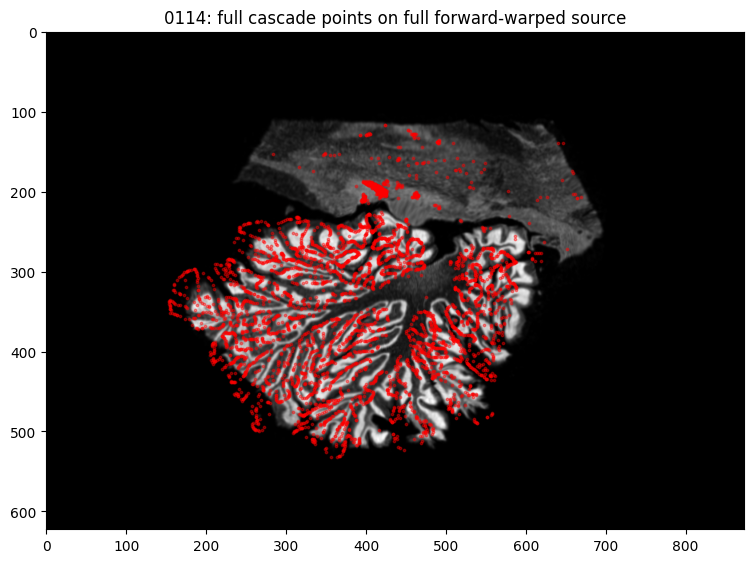

In [55]:
def fwd_paths_for(stem, zid):
    return [os.path.join(stage_dir(s, zid), f"{stem}_{s}-map.nii.gz") for s in fname_suffixes]
zid = have[0]; stem, inv_paths = manifest[zid]
fwd_paths = fwd_paths_for(stem, zid)

src = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz"))
seq = src
for p in fwd_paths:
    seq = apply_coordinate_mapping_2d(seq, nb.load(p))
seq = seq.get_fdata(); seq = seq[..., 0] if seq.ndim == 3 else seq

pts_full = df_all.loc[df_all.zefir_id == zid, ["row", "col"]].to_numpy(float)
ps, inb, off = prep_points(pts_full, slice_full_shape(zid), nb.load(inv_paths[0]).shape[:2])
pw = warp_points(ps, [nb.load(p) for p in inv_paths]); v = np.isfinite(pw).all(1)

plt.figure(figsize=(9, 9)); plt.imshow(seq, cmap="gray")
plt.scatter(pw[v, 1], pw[v, 0], s=3, c="red", alpha=.4)
plt.title(f"{zid}: full cascade points on full forward-warped source"); plt.show()

In [56]:
zid = have[0]; stem = manifest[zid][0]
print("init dir:", glob.glob(os.path.join(reg_dir, f"init_translation_slice_{zid}", f"{stem}_coreg0nl_ants-*map.nii.gz")))
print("reg_dir :", glob.glob(os.path.join(reg_dir, f"{stem}_coreg0nl_ants-*map.nii.gz")))

init dir: ['/data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz', '/data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz']
reg_dir : []


stage1 inv: /data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz
stage1 fwd: /data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz


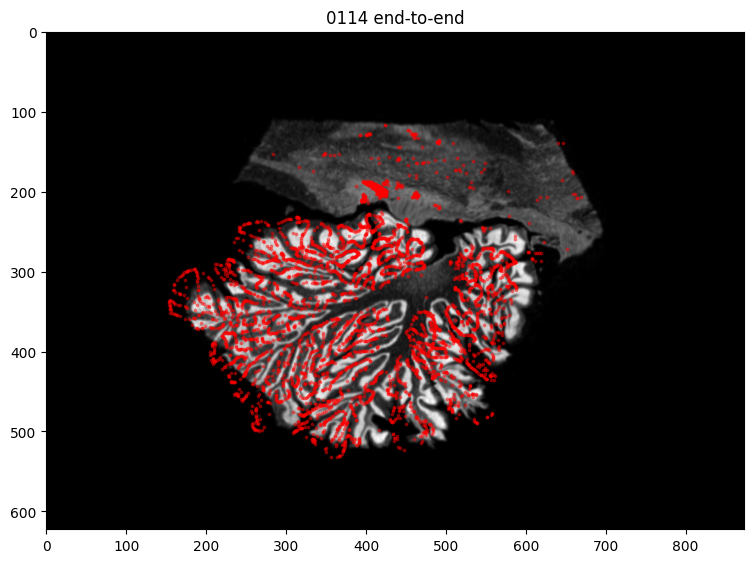

In [57]:
zid = have[0]; stem, inv_paths = manifest[zid]
fwd_paths = [os.path.join(stage_dir(s, zid), f"{stem}_{s}-map.nii.gz") for s in fname_suffixes]
print("stage1 inv:", inv_paths[0])
print("stage1 fwd:", fwd_paths[0])
for p in inv_paths + fwd_paths:
    assert os.path.exists(p), f"MISSING {p}"

src = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz"))
seq = src
for p in fwd_paths:
    seq = apply_coordinate_mapping_2d(seq, nb.load(p))
seq = seq.get_fdata(); seq = seq[..., 0] if seq.ndim == 3 else seq

pts_full = df_all.loc[df_all.zefir_id == zid, ["row", "col"]].to_numpy(float)
ps, inb, off = prep_points(pts_full, slice_full_shape(zid), nb.load(inv_paths[0]).shape[:2])
pw = warp_points(ps, [nb.load(p) for p in inv_paths]); v = np.isfinite(pw).all(1)

plt.figure(figsize=(9, 9)); plt.imshow(seq, cmap="gray")
plt.scatter(pw[v, 1], pw[v, 0], s=3, c="red", alpha=.4)
plt.title(f"{zid} end-to-end"); plt.show()

In [ ]:
zid = have[0]; stem = manifest[zid][0]
print("init dir:", glob.glob(os.path.join(reg_dir, f"init_translation_slice_{zid}", f"{stem}_coreg0nl_ants-*map.nii.gz")))
print("reg_dir :", glob.glob(os.path.join(reg_dir, f"{stem}_coreg0nl_ants-*map.nii.gz")))

init dir: ['/data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz', '/data2/neuralabc/johmat/zefir_sliceReg_optimized_v2_rescale_5/init_translation_slice_0114/zefir_0114__Image_02_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz']
reg_dir : []


TypeError: prep_points() takes 3 positional arguments but 4 were given

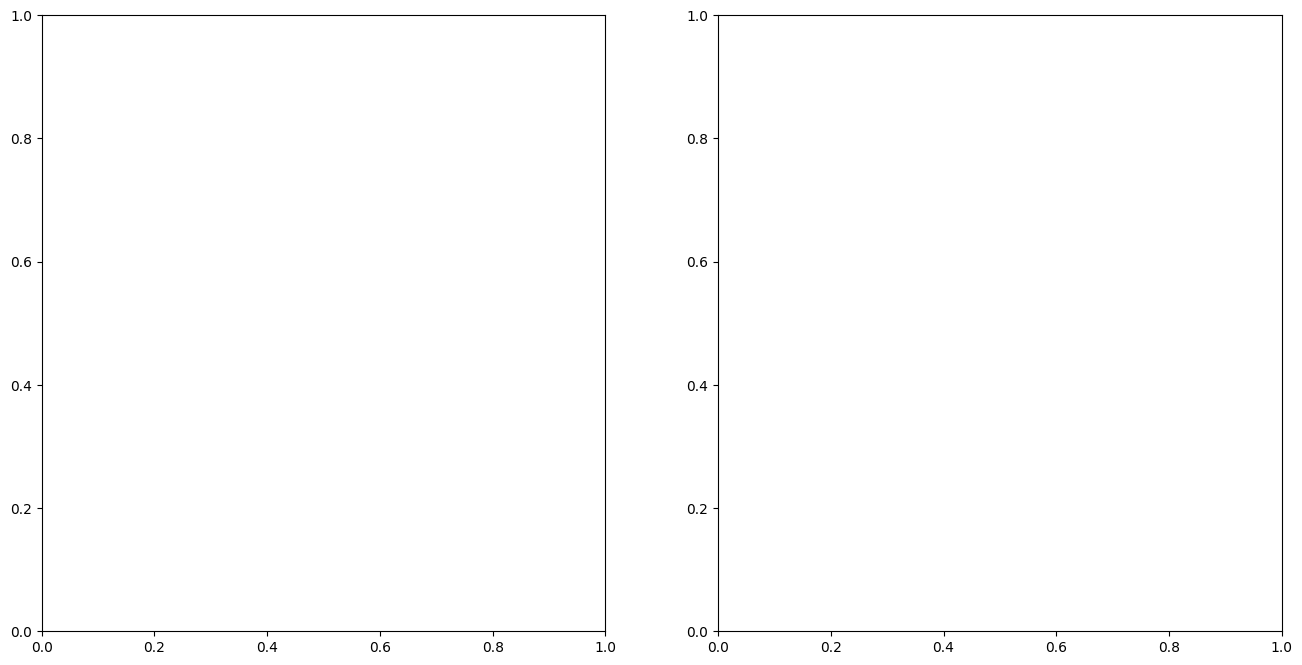

In [22]:
zid = have[0]; stem, inv_paths = manifest[zid]
src_grid_shape = nb.load(inv_paths[0]).shape[:2]
src_img = nb.load(os.path.join(reg_dir, f"{stem}.nii.gz")).get_fdata()   # registration input grid
if src_img.ndim == 3: src_img = src_img[..., 0]
full_shape = slice_full_shape(zid)
pts_full = df_all.loc[df_all.zefir_id == zid, ["row", "col"]].to_numpy(float)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
for a, p in zip(ax, (0.0, 0.2)):
    ps, inb, off = prep_points(pts_full, full_shape, src_grid_shape, p)
    a.imshow(src_img, cmap="gray")
    a.scatter(ps[:, 1], ps[:, 0], s=3, c="red", alpha=.5)
    a.set_title(f"prop_pad={p}  off={off}  in={inb.sum()}/{len(inb)}")
plt.show()
print("src grid:", src_grid_shape)   

In [ ]:
aff_ref = None
for zid in have:
    out = os.path.join(out_dir, f"zefirID_{zid}_counts.nii.gz")
    if os.path.exists(out):
        continue
    stem, inv_paths = manifest[zid]
    counts, aff, st = process_slice(zid, stem, inv_paths, prop_pad=PROP_PAD)
    aff_ref = aff if aff_ref is None else aff_ref
    tmp = out + ".tmp.nii.gz"
    nb.save(nb.Nifti1Image(counts[..., None].astype(np.float32), aff), tmp)
    os.replace(tmp, out)
    print(zid, st, flush=True)

In [ ]:
pts_final = apply_inverse_coordinate_mapping_2d(
    apply_inverse_coordinate_mapping_2d(
        apply_inverse_coordinate_mapping_2d(
            apply_inverse_coordinate_mapping_2d(
                apply_inverse_coordinate_mapping_2d(
                    apply_inverse_coordinate_mapping_2d(
                        apply_inverse_coordinate_mapping_2d(
                            apply_inverse_coordinate_mapping_2d(
                                apply_inverse_coordinate_mapping_2d(
                                    pts_src, inv1), inv2), inv3), inv4), inv5), inv6), inv7), inv8), inv9)

In [ ]:
mx, my = src_grid_shape
probe = np.array([[mx*0.3, my*0.3], [mx*0.5, my*0.5], [mx*0.7, my*0.6], [mx*0.4, my*0.8]])

fwd  = warp_points(probe, [inv1, inv2])                 # src -> stage2 target
back = warp_points(fwd, [m2.get_fdata(), m1.get_fdata()])  # back: maps in reverse order
resid = back - probe
print("max abs residual (px):", np.nanmax(np.abs(resid)))
print(resid)

In [ ]:
import cv2
mfile = glob.glob(os.path.join(mask_dir, "*zefirID_0116_*mask*.ome.tif"))
assert len(mfile) == 1, f"expected 1 mask, got {mfile}"
mask_bin = tiff.imread(mfile[0]).astype(bool).astype(np.uint8)
print("full-res mask:", mask_bin.shape)

# full-res centroids. cv2 returns centroids as (x=col, y=row) -> swap to (axis0,axis1).
# NOTE int32 overflow if this slide is one of the ~4.67B px ones; validation masks are
# usually regional so likely fine. If it crashes, point me to the QuPath annotation CSV instead.
n, _, _, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)
pts_full = centroids[1:, [1, 0]]   # drop background label 0, -> (row, col)
print("cells:", len(pts_full))

# build the src-grid mask exactly as the pipeline does
_ds = downsample_image(mask_bin, rescale, prop_pad=0)
src_grid_mask = center_crop_or_pad_2d(_ds, target_shape=src_grid_shape)

# derive the crop/pad offset empirically (survives odd-difference / crop-vs-pad)
ci, cj = _ds.shape[0] // 2, _ds.shape[1] // 2
probe_img = np.zeros(_ds.shape, np.float32); probe_img[ci, cj] = 1
probe_cp  = center_crop_or_pad_2d(probe_img, target_shape=src_grid_shape)
yi, xi = np.argwhere(probe_cp == 1)[0]
off = np.array([yi - ci, xi - cj])   # src_coord = floor(full/rescale) + off
print("crop/pad offset:", off)

# prep: floor-downsample (matches block reduction) + offset
pts_src = np.floor(pts_full / rescale) + off
inb = ((pts_src >= 0) & (pts_src < np.array(src_grid_shape))).all(axis=1)
print(f"in-bounds after prep: {inb.sum()}/{len(pts_src)}")
pts_src = pts_src[inb]

plt.figure(figsize=(9, 9))
plt.imshow(src_grid_mask, cmap='gray')
plt.scatter(pts_src[:, 1], pts_src[:, 0], s=4, c='red', alpha=0.6)  # col=x, row=y
plt.title("prep check: red points must sit on blobs"); plt.show()

In [ ]:
pts_warp = warp_points(pts_src, [inv1, inv2])
lost = ~np.isfinite(pts_warp).all(axis=1)
print(f"warped out of bounds: {lost.sum()}/{len(pts_warp)}")

seed = nb.Nifti1Image(src_grid_mask.astype(np.float32), inv1_affine := nb.load(
    os.path.join(reg_dir, f"{base_slice}_coreg0nl_ants-invmap.nii.gz")).affine)
img_warp = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(seed, m1), m2).get_fdata()
if img_warp.ndim == 3: img_warp = img_warp[:, :, 0]

plt.figure(figsize=(9, 9))
plt.imshow(img_warp, cmap='gray')
plt.scatter(pts_warp[~lost, 1], pts_warp[~lost, 0], s=4, c='red', alpha=0.6)
plt.title("consistency: warped points must sit on warped blobs"); plt.show()